In [8]:
import pandas as pd
import numpy as np
import math
import datetime as dt
from matplotlib import pyplot as plt

import os
import shutil
import glob

from netCDF4 import Dataset
import xarray as xr

from scipy.interpolate import griddata
from scipy.signal import argrelextrema, find_peaks

In [14]:
uiuc_directory = './data/02_processed/UIUC'
uiuc_files = [txt for txt in os.listdir(uiuc_directory) if txt.endswith('.csv')]
print(len(uiuc_files))

9453


In [15]:
uiuc_files[0]

'R18B0218.332695.csv'

In [11]:


f = os.path.join(uiuc_directory, uiuc_files[100])


meta_data = []
shot_data = []

bin_width = 3.5
lidar_height = 1.8
origin_X = 50
origin_Y = 50
origin_Z = 50
origin_Azimuth = 110
origin_Zenith = 0

with open(f, 'r') as file:
    content = file.readlines()
    meta = content[0:7]
    header1 = meta[0]
    header2 = meta[1]
    header3 = meta[2]
    header4 = meta[3]
    header5 = meta[4]
    header6 = meta[5]
    header7 = meta[6]
    
    header2 = header2.split(' ')
    campaign = header2[0]
    startDate = f'{header2[1]} {header2[2]}'
    endDate = f'{header2[3]} {header2[4]}'
    elevation = float(header2[5])
    longitude = float(header2[6])
    latitude = float(header2[7])
    zenith = float(header2[8])*-1
    azimuth = float(header2[9])
    temp_ground = float(header2[10])
    pressure = float(header2[11])
    bin_width = float(header5.split()[6])

df = pd.read_csv(f, skiprows=14)
df['source'] = 'UIUC'
df['timestamp'] = pd.to_datetime(startDate, dayfirst=True)
df['distance'] = (df.index+1)*bin_width 
df['azimuth'] = azimuth
df['zenith'] = zenith
df['analog'] = df['0 (mV)']

df['x'] = origin_X + df['distance'] * np.cos(np.radians(zenith+origin_Zenith)) * np.sin(np.radians(azimuth+origin_Azimuth))
df['y'] = origin_Y + df['distance'] * np.cos(np.radians(zenith+origin_Zenith)) * np.cos(np.radians(azimuth+origin_Azimuth))
df['z'] = origin_Z + df['distance'] * np.sin(np.radians(zenith+origin_Zenith)) + lidar_height
    
    

In [12]:
df

,0 (mV),1 (counts),2 (mV),3 (counts),4 (mV),5 (counts),6 (mV),7 (counts),8 (counts),9 (counts),source,timestamp,distance,azimuth,zenith,analog,x,y,z
0,9.5238,44.0,0.0,0.0,9.4401,66.0,0.0,0.0,23.0,0.0,UIUC,2018-11-03 02:47:18,3.75,24.0,2.6,9.5238,52.694747,47.397713,50.170111
1,9.4976,67.0,0.0,0.0,9.4209,65.0,0.0,0.0,32.0,0.0,UIUC,2018-11-03 02:47:18,7.50,24.0,2.6,9.4976,55.389495,44.795425,50.340222
2,9.4889,65.0,0.0,0.0,9.4244,79.0,0.0,0.0,35.0,0.0,UIUC,2018-11-03 02:47:18,11.25,24.0,2.6,9.4889,58.084242,42.193138,50.510334
3,9.4279,59.0,0.0,0.0,9.4192,82.0,0.0,0.0,36.0,0.0,UIUC,2018-11-03 02:47:18,15.00,24.0,2.6,9.4279,60.778989,39.590851,50.680445
4,9.5413,75.0,0.0,0.0,9.4314,93.0,0.0,0.0,51.0,0.0,UIUC,2018-11-03 02:47:18,18.75,24.0,2.6,9.5413,63.473737,36.988564,50.850556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14737,9.5238,0.0,0.0,0.0,9.4401,0.0,0.0,0.0,0.0,0.0,UIUC,2018-11-03 02:47:18,55267.50,24.0,2.6,9.5238,39765.186272,-38302.509572,2557.098946
14738,9.5761,0.0,0.0,0.0,9.4366,0.0,0.0,0.0,0.0,0.0,UIUC,2018-11-03 02:47:18,55271.25,24.0,2.6,9.5761,39767.881019,-38305.111860,2557.269058
14739,9.5500,0.0,0.0,0.0,9.4471,0.0,0.0,0.0,0.0,0.0,UIUC,2018-11-03 02:47:18,55275.00,24.0,2.6,9.5500,39770.575767,-38307.714147,2557.439169
14740,9.5151,0.0,0.0,0.0,9.4523,0.0,0.0,0.0,0.0,0.0,UIUC,2018-11-03 02:47:18,55278.75,24.0,2.6,9.5151,39773.270514,-38310.316434,2557.609280


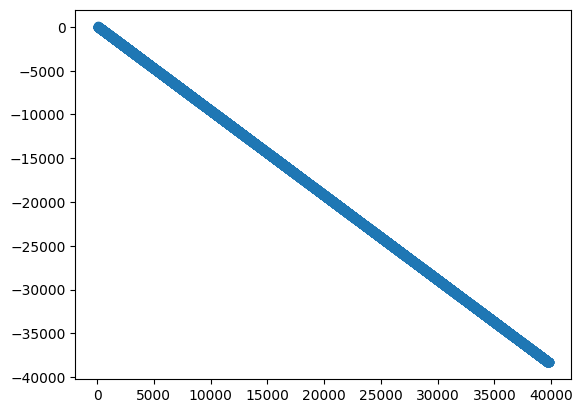

In [13]:
plt.scatter(df['x'], df['y'])
plt.show()

In [68]:
print(latitude, longitude*-1)
print(startDate)

38.0631 -23.7534
02/11/2018 17:31:02


In [69]:
df['timestamp']

0       2018-11-02 17:31:02
1       2018-11-02 17:31:02
2       2018-11-02 17:31:02
3       2018-11-02 17:31:02
4       2018-11-02 17:31:02
                ...        
16375   2018-11-02 17:31:02
16376   2018-11-02 17:31:02
16377   2018-11-02 17:31:02
16378   2018-11-02 17:31:02
16379   2018-11-02 17:31:02
Name: timestamp, Length: 16380, dtype: datetime64[ns]

In [5]:
df
    

,0 (mV),1 (counts),2 (mV),3 (counts),4 (mV),5 (counts),6 (mV),7 (counts),8 (counts),9 (counts),timestamp,distance,azimuth,zenith,analog
0,9.6785,26.0,0.0,0.0,9.4799,41.0,0.0,0.0,19.0,0.0,2018-11-02 23:48:43,3.75,24.0,6.4,9.6785
1,9.7029,34.0,0.0,0.0,9.4847,51.0,0.0,0.0,25.0,0.0,2018-11-02 23:48:43,7.50,24.0,6.4,9.7029
2,9.6459,39.0,0.0,0.0,9.4847,47.0,0.0,0.0,36.0,0.0,2018-11-02 23:48:43,11.25,24.0,6.4,9.6459
3,9.6540,32.0,0.0,0.0,9.4815,52.0,0.0,0.0,26.0,0.0,2018-11-02 23:48:43,15.00,24.0,6.4,9.6540
4,9.6215,41.0,0.0,0.0,9.4847,67.0,0.0,0.0,49.0,0.0,2018-11-02 23:48:43,18.75,24.0,6.4,9.6215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14721,9.7110,0.0,0.0,0.0,9.4538,0.0,0.0,0.0,0.0,0.0,2018-11-02 23:48:43,55207.50,24.0,6.4,9.7110
14722,9.7110,0.0,0.0,0.0,9.4652,0.0,0.0,0.0,0.0,0.0,2018-11-02 23:48:43,55211.25,24.0,6.4,9.7110
14723,9.7110,0.0,0.0,0.0,9.4799,0.0,0.0,0.0,0.0,0.0,2018-11-02 23:48:43,55215.00,24.0,6.4,9.7110
14724,9.7110,0.0,0.0,0.0,9.4701,0.0,0.0,0.0,0.0,0.0,2018-11-02 23:48:43,55218.75,24.0,6.4,9.7110


In [71]:
df.columns

Index(['0 (mV)', ' 1 (counts)', ' 2 (mV)', ' 3 (counts)', ' 4 (mV)',
       ' 5 (counts)', ' 6 (mV)', ' 7 (counts)', ' 8 (counts)', ' 9 (counts)',
       'timestamp', 'distance', 'azimuth', 'zenith', 'rc_value'],
      dtype='object')

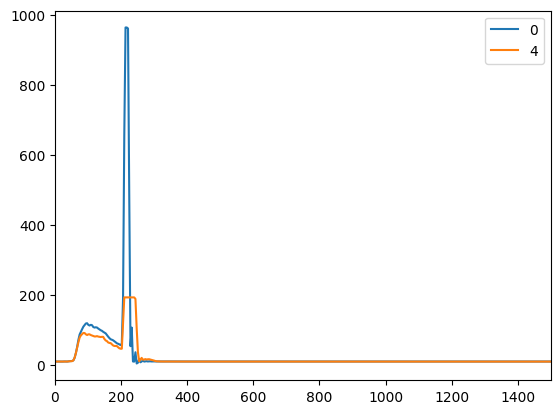

In [72]:
plt.plot(df['distance'], df['0 (mV)'], label='0')
plt.plot(df['distance'], df[' 4 (mV)'], label='4' )
plt.xlim(0, 1500)
plt.legend()
plt.show()

KeyError: '0 (mV)'

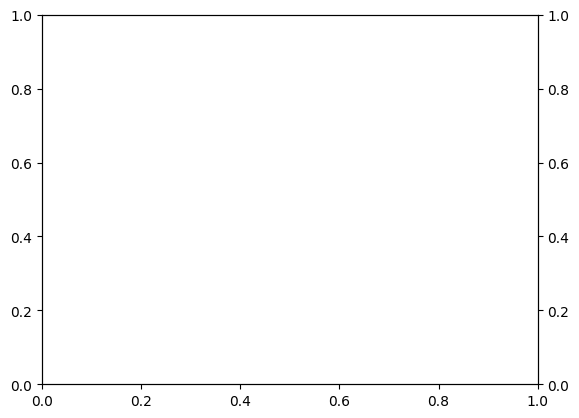

In [95]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

line1 = ax1.plot(df['distance'], df['0 (mV)'], color='blue', label='0')
line2 = ax2.plot(df['distance'], df['rc_value'], color='red', label='Range Corrected')

# Optional: Set labels for the axes
ax1.set_xlabel("X-axis Label")
ax1.set_ylabel("Y1 Units", color='blue')
ax2.set_ylabel("Y2 Units", color='red')

# plt.xlim(0, 1500)
plt.legend()
plt.show()

USC Data

In [96]:
usc_directory = './data/02_processed/USC'
usc_files = [txt for txt in os.listdir(usc_directory) if txt.endswith('.txt')]
print(len(usc_files))

9370


In [100]:
origin_X = 50
origin_Y = 50
origin_Z = 50
origin_Azimuth = 110


f = os.path.join(usc_directory, usc_files[50])
meta_data = []
shot_data = []
with open(f, 'r') as file:
    content = file.readlines()

    # The first seven lines are meta data
    meta = content[0:7]
    
    header1 = meta[0]
    header2 = meta[1]
    header3 = meta[2]
    header4 = meta[3]
    header5 = meta[4]
    header6 = meta[5]
    header7 = meta[6]
    
    header2 = header2.split(' ')
    campaign = header2[0]
    startDate = f'{header2[3]} {header2[4]}'
    endDate = f'{header2[5]} {header2[6]}'
    elevation = float(header2[7])
    longitude = float(header2[8])
    latitude = float(header2[9])
    zenith = float(header2[10])*-1
    azimuth = float(header2[11])
    temp_ground = float(header2[12])
    pressure = float(header2[13])
    bin_width = float(header5.split()[6])
    data = content[7:]

my_data = []
for row in data:
    d = row.strip().split('\t')
    my_data.append(d)
df = pd.DataFrame(my_data, columns=['analog', 'photon'])
df = df.apply(pd.to_numeric)
df['angle'] = azimuth
df['start'] = startDate
df['start'] = pd.to_datetime(df['start'])
df['end'] = endDate
df['end'] = pd.to_datetime(df['end'])
df['distance'] = (df.index +1) * bin_width


df['x'] = origin_X + df['distance'] * np.cos(np.radians(zenith)) * np.sin(np.radians(azimuth+origin_Azimuth))
df['y'] = origin_Y + df['distance'] * np.cos(np.radians(zenith)) * np.cos(np.radians(azimuth+origin_Azimuth))
df['z'] = origin_Z + df['distance'] * np.sin(np.radians(zenith))

df

,analog,photon,angle,start,end,distance,x,y,z
0,4.7078,43.3333,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,7.5,56.892665,47.045800,50.117805
1,4.7201,100.0000,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,15.0,63.785329,44.091600,50.235610
2,4.7078,86.6667,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,22.5,70.677994,41.137401,50.353415
3,4.7078,76.6667,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,30.0,77.570658,38.183201,50.471220
4,4.6834,136.6667,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,37.5,84.463323,35.229001,50.589024
...,...,...,...,...,...,...,...,...,...
16335,4.7119,0.0000,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,122520.0,112648.569046,-48209.808336,1974.460517
16336,4.6916,0.0000,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,122527.5,112655.461710,-48212.762536,1974.578322
16337,4.6956,0.0000,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,122535.0,112662.354375,-48215.716735,1974.696127
16338,4.7119,0.0000,3.2,2018-02-11 14:58:46,2018-02-11 14:58:46,122542.5,112669.247039,-48218.670935,1974.813932


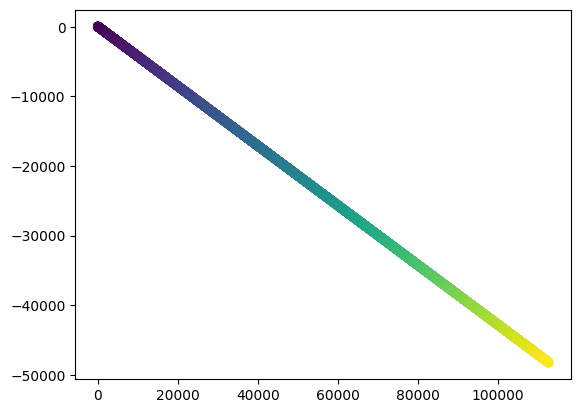

In [103]:
plt.scatter(df['x'], df['y'], c=df['z'])

In [85]:
Ranges=np.arange(7.5,df['distance'].max()+1,7.5)

xrange = np.arange(7.5,df['distance'].max()+1,7.5)
range_corr = np.ones(len(xrange)) * xrange**2

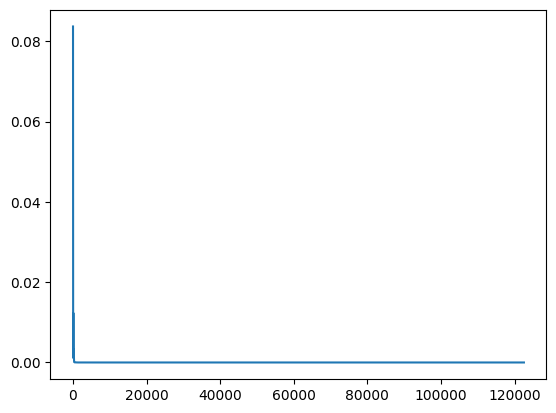

In [93]:
plt.plot(df['distance'], df['analog']/(df['distance']**2))
plt.show()


In [6]:
meta_df = pd.DataFrame(columns=['file', 'start', 'end', 'elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure'])

# Convert appropriate columns to numeric
numeric_cols = ['elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure']
# meta_df[numeric_cols] = meta_df[numeric_cols].apply(pd.to_numeric, errors='coerce')  # Convert and set non-numeric values to NaN

for txt_file in files_to_read:
    f = os.path.join(directory, txt_file)
    meta_data = []
    shot_data = []
    with open(f, 'r') as file:
        content = file.readlines()
    
        # The first seven lines are meta data
        meta = content[0:7]
        
        header1 = meta[0]
        header2 = meta[1]
        header3 = meta[2]
        header4 = meta[3]
        header5 = meta[4]
        header6 = meta[5]
        header7 = meta[6]
        
        header2 = header2.split(' ')
        campaign = header2[0]
        startDate = f'{header2[3]} {header2[4]}'
        endDate = f'{header2[5]} {header2[6]}'
        elevation = float(header2[7])
        longitude = float(header2[8])
        latitude = float(header2[9])
        zenith = float(header2[10])*-1
        azimuth = float(header2[11])
        temp_ground = float(header2[12])
        pressure = float(header2[13])
        bin_width = float(header5.split()[6])
        data = content[7:]
    
    # Create a dataframe for the meta data
    meta_data.append([f, startDate, endDate, elevation, longitude, latitude, zenith, azimuth, temp_ground, pressure])
    
    # Create DF
    temp_meta_df = pd.DataFrame(meta_data, columns=['file', 'start', 'end', 'elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure'])
    
    # Convert appropriate columns to numeric
    # numeric_cols = ['elevation', 'longitude', 'latitude', 'zenith', 'azimuth', 'temp_ground', 'pressure']
    # temp_meta_df[numeric_cols] = temp_meta_df[numeric_cols].apply(pd.to_numeric, errors='coerce')  # Convert and set non-numeric values to NaN
    
    # Convert date columns to datetime
    temp_meta_df['start'] = pd.to_datetime(temp_meta_df['start'], errors='coerce', dayfirst=True)
    temp_meta_df['end'] = pd.to_datetime(temp_meta_df['end'], errors='coerce', dayfirst=True)
    meta_df = pd.concat([meta_df, temp_meta_df], ignore_index=True)
meta_df = meta_df.sort_values('start')
print( meta_df)

IndexError: list index out of range

In [7]:
import re

In [24]:
coords = ''' 40° 12’ 35.97"N,88° 24’ 16.03"W
 40° 12’ 37.23”N,88° 24’ 14.27”W
 40° 12’ 34”N,88° 24’ 21”W
40° 12’ 37.23”N,88° 24’ 14.27”W
40° 12’ 42.6"N,88° 24’ 26.2"W
40° 12’ 34.31”N,88° 24’ 03.55”W'''

for line in coords.split('\n'):
    print(line)

 40° 12’ 35.97"N,88° 24’ 16.03"W
 40° 12’ 37.23”N,88° 24’ 14.27”W
 40° 12’ 34”N,88° 24’ 21”W
40° 12’ 37.23”N,88° 24’ 14.27”W
40° 12’ 42.6"N,88° 24’ 26.2"W
40° 12’ 34.31”N,88° 24’ 03.55”W


In [25]:
for line in coords.split('\n'):
    latitude, longitude = line.split(',')
    degree_lat = latitude.split('°')
    # minutes_lat =
    # seconds_lat =
    
    degree_lon = longitude.split('°')
    # minutes_lat =
    # seconds_lat =

    print(degree_lat, degree_lon)
    

[' 40', ' 12’ 35.97"N'] ['88', ' 24’ 16.03"W']
[' 40', ' 12’ 37.23”N'] ['88', ' 24’ 14.27”W']
[' 40', ' 12’ 34”N'] ['88', ' 24’ 21”W']
['40', ' 12’ 37.23”N'] ['88', ' 24’ 14.27”W']
['40', ' 12’ 42.6"N'] ['88', ' 24’ 26.2"W']
['40', ' 12’ 34.31”N'] ['88', ' 24’ 03.55”W']
